In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

pd.set_option("display.max_columns", None)

In [2]:
# Step 2: Load prepared dataset

df = pd.read_csv("../data/heart_disease_model_ready.csv")

df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk_factor_count,total_poor_health_days,Diabetes_1.0,Diabetes_2.0
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,4.0,33.0,0,0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,1.0,0.0,0,0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,3.0,60.0,0,0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,1.0,0.0,0,0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,2.0,3.0,0,0


In [3]:
# Step 3: Load saved Logistic Regression model and scaler

model = joblib.load("../models/logistic_regression_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Model and scaler loaded successfully")

Model and scaler loaded successfully


In [4]:
# Step 4: Separate features and target variable

X = df.drop("HeartDiseaseorAttack", axis=1)
y = df["HeartDiseaseorAttack"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (253680, 24)
Target shape: (253680,)


In [5]:
# Step 5: Scale features using the saved scaler

X_scaled = scaler.transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk_factor_count,total_poor_health_days,Diabetes_1.0,Diabetes_2.0
0,1.153145,1.163749,0.196638,1.757533,1.121032,-0.205042,-1.764112,-1.318210,0.481355,-0.243585,0.227383,-0.302541,2.328266,1.997721,1.237189,2.226320,-0.886181,0.315398,-1.066341,-1.474649,1.731023,1.926180,-0.136909,-0.402596
1,-0.867193,-0.859292,-5.085490,-0.511433,1.121032,-0.205042,0.566857,-1.318210,-2.077467,-0.243585,-4.397861,3.305337,0.457064,-0.429641,-0.486428,-0.449172,-0.886181,-0.339454,0.963758,-2.440383,-0.491288,-0.558649,-0.136909,-0.402596
2,1.153145,1.163749,0.196638,-0.057640,-0.892035,-0.205042,-1.764112,0.758605,-2.077467,-0.243585,0.227383,3.305337,2.328266,3.615961,2.960806,2.226320,-0.886181,0.315398,-1.066341,0.939685,0.990252,3.959222,-0.136909,-0.402596
3,1.153145,-0.859292,0.196638,-0.208905,-0.892035,-0.205042,0.566857,0.758605,0.481355,-0.243585,0.227383,-0.302541,-0.478538,-0.429641,-0.486428,-0.449172,-0.886181,0.970250,-2.081390,-0.026049,-0.491288,-0.558649,-0.136909,-0.402596
4,1.153145,1.163749,0.196638,-0.662698,-0.892035,-0.205042,0.566857,0.758605,0.481355,-0.243585,0.227383,-0.302541,-0.478538,-0.025080,-0.486428,-0.449172,-0.886181,0.970250,-0.051292,-0.991782,0.249482,-0.332755,-0.136909,-0.402596


In [6]:
# Step 6: Create sample data for SHAP analysis

X_sample = X.sample(n=5000, random_state=42)
X_sample_scaled = scaler.transform(X_sample)

X_sample_scaled_df = pd.DataFrame(X_sample_scaled, columns=X.columns)

X_sample_scaled_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk_factor_count,total_poor_health_days,Diabetes_1.0,Diabetes_2.0
0,-0.867193,-0.859292,0.196638,-1.116491,-0.892035,-0.205042,-1.764112,0.758605,0.481355,-0.243585,0.227383,-0.302541,0.457064,-0.025080,0.317927,-0.449172,-0.886181,-0.339454,-1.066341,-1.957516,-1.232058,0.194330,-0.136909,-0.402596
1,1.153145,1.163749,0.196638,-0.057640,-0.892035,-0.205042,0.566857,0.758605,0.481355,-0.243585,0.227383,-0.302541,0.457064,-0.429641,-0.486428,-0.449172,-0.886181,1.625101,0.963758,-0.026049,0.249482,-0.558649,-0.136909,-0.402596
2,-0.867193,-0.859292,0.196638,-0.662698,-0.892035,-0.205042,0.566857,0.758605,0.481355,-0.243585,0.227383,-0.302541,-1.414139,-0.429641,-0.486428,-0.449172,1.128438,-2.304008,-1.066341,0.456818,-1.232058,-0.558649,-0.136909,-0.402596
3,-0.867193,-0.859292,0.196638,-0.208905,1.121032,-0.205042,0.566857,-1.318210,0.481355,4.105336,0.227383,-0.302541,-0.478538,-0.025080,-0.486428,-0.449172,1.128438,-1.976583,-1.066341,0.456818,-0.491288,-0.332755,-0.136909,-0.402596
4,-0.867193,1.163749,0.196638,0.396153,1.121032,-0.205042,-1.764112,0.758605,0.481355,-0.243585,0.227383,3.305337,1.392665,3.211401,2.616082,2.226320,-0.886181,-0.012028,-2.081390,-1.957516,0.990252,3.507435,-0.136909,-0.402596


In [7]:
# Step 7: Create SHAP explainer for Logistic Regression

explainer = shap.LinearExplainer(
    model,
    X_sample_scaled_df
)

print("SHAP explainer created successfully")

SHAP explainer created successfully


In [8]:
# Step 8: Calculate SHAP values

shap_values = explainer(X_sample_scaled_df)

print("SHAP values calculated successfully")

SHAP values calculated successfully


In [9]:
# Step 9: Check SHAP values shape

shap_values.values.shape

(5000, 24)

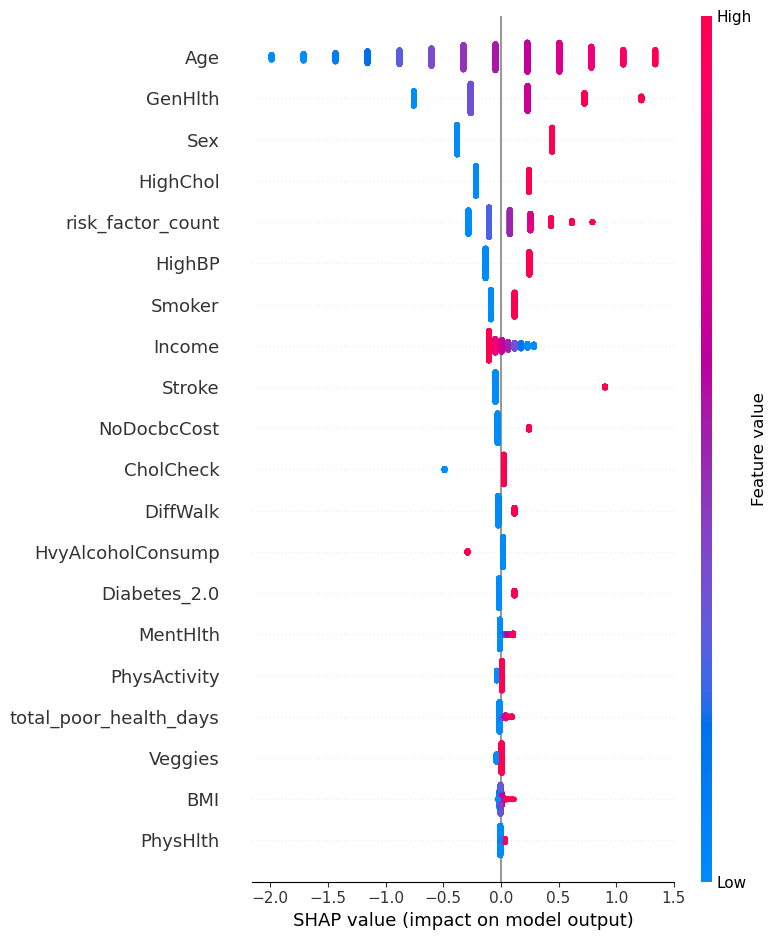

In [10]:
# Step 10: Create SHAP summary plot

shap.summary_plot(
    shap_values,
    X_sample_scaled_df,
    feature_names=X.columns
)

### Interpretation

The SHAP summary plot shows which features have the strongest overall influence on the Logistic Regression model predictions.

Features at the top have the greatest impact on the model output. SHAP helps explain not only which features are important, but also whether they push the prediction toward higher or lower heart disease/heart attack risk.

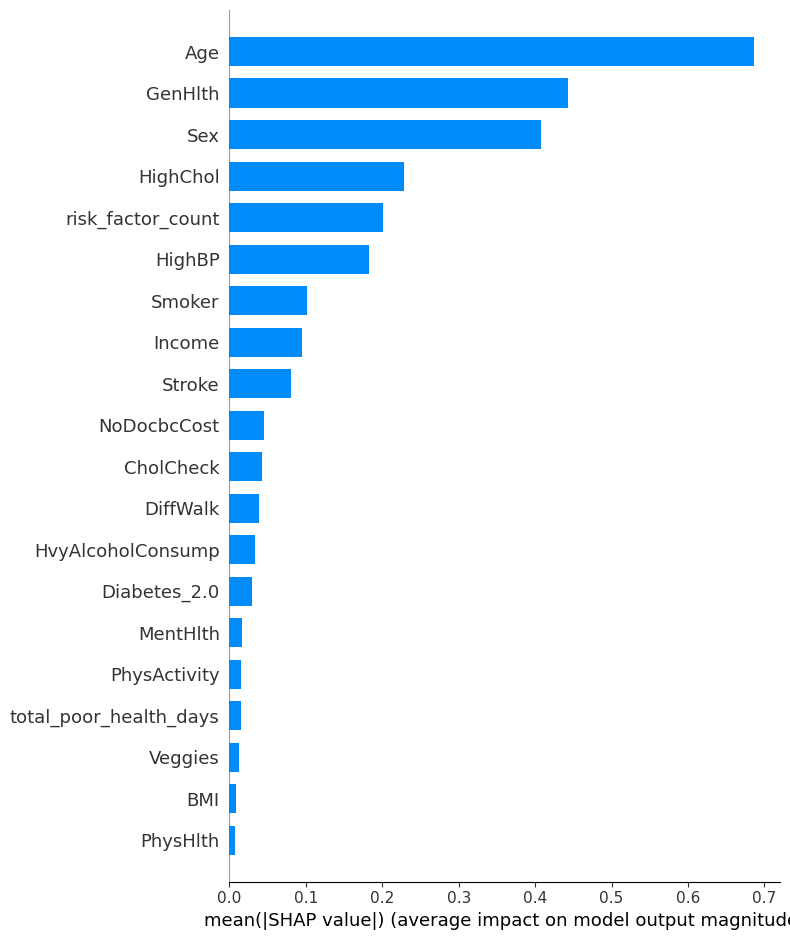

In [11]:
# Step 11: Create SHAP bar plot for global feature importance

shap.summary_plot(
    shap_values,
    X_sample_scaled_df,
    feature_names=X.columns,
    plot_type="bar"
)

### Interpretation

The SHAP bar plot shows the average importance of each feature across the sample data. Features with larger SHAP values have a stronger overall influence on the model prediction.

This plot is useful for the capstone presentation because it clearly ranks the most important features affecting heart disease/heart attack prediction.

In [12]:
# Step 12: Calculate mean absolute SHAP values

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean Absolute SHAP Value": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean Absolute SHAP Value",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean Absolute SHAP Value
17,Age,0.686122
12,GenHlth,0.442938
16,Sex,0.408225
1,HighChol,0.227950
20,risk_factor_count,0.201181
0,HighBP,0.182037
4,Smoker,0.100845
19,Income,0.094528
5,Stroke,0.081061
11,NoDocbcCost,0.045830


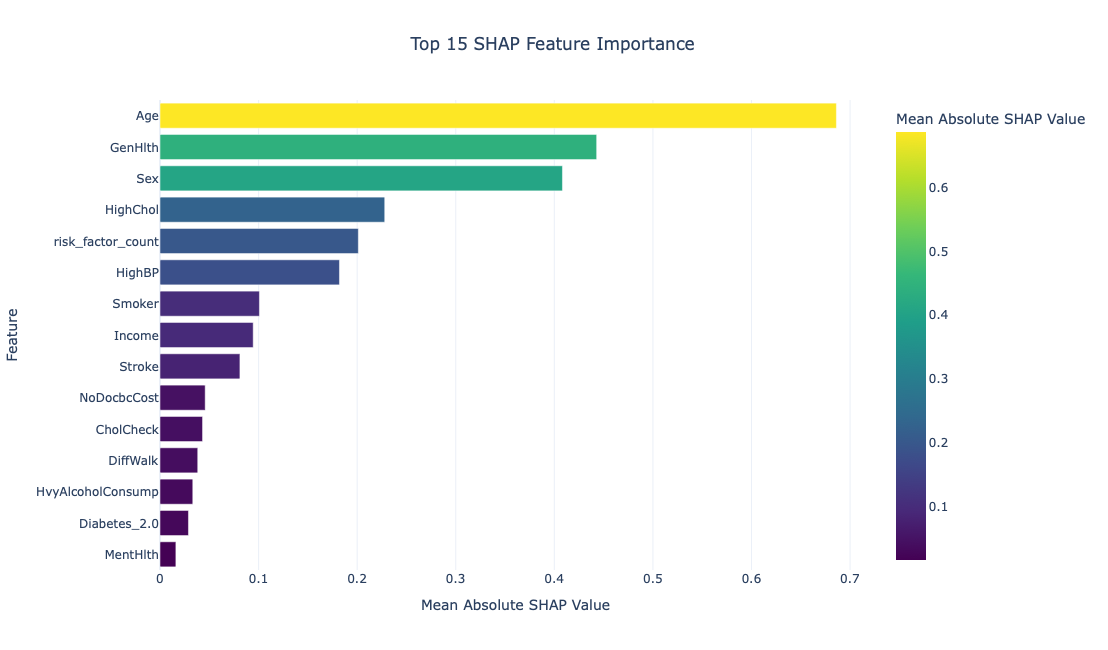

In [13]:
# Step 13: Visualise top 15 SHAP important features

import plotly.express as px

top_shap_features = shap_importance.head(15)

fig = px.bar(
    top_shap_features.sort_values(by="Mean Absolute SHAP Value"),
    x="Mean Absolute SHAP Value",
    y="Feature",
    orientation="h",
    title="Top 15 SHAP Feature Importance",
    color="Mean Absolute SHAP Value",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_title="Mean Absolute SHAP Value",
    yaxis_title="Feature",
    title_x=0.5,
    template="plotly_white",
    width=900,
    height=650
)

fig

### Interpretation

The top SHAP features represent the variables that most strongly influenced the Logistic Regression model predictions. These features will be useful for explaining the model in the final dashboard, app, and capstone presentation.

In [14]:
# Step 14: Explain one individual prediction

sample_index = 0

single_prediction_data = X_sample_scaled_df.iloc[[sample_index]].values
single_original_data = X_sample.iloc[[sample_index]]

single_probability = model.predict_proba(single_prediction_data)[0][1]
single_prediction = model.predict(single_prediction_data)[0]

print("Prediction:", single_prediction)
print("Predicted probability of heart disease/attack:", round(single_probability, 4))

Prediction: 0.0
Predicted probability of heart disease/attack: 0.1245


In [15]:
# Step 15: Display original feature values for the selected individual

single_original_data

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk_factor_count,total_poor_health_days,Diabetes_1.0,Diabetes_2.0
219620,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,3.0,7.0,0.0,0.0,7.0,4.0,2.0,0.0,10.0,0,0


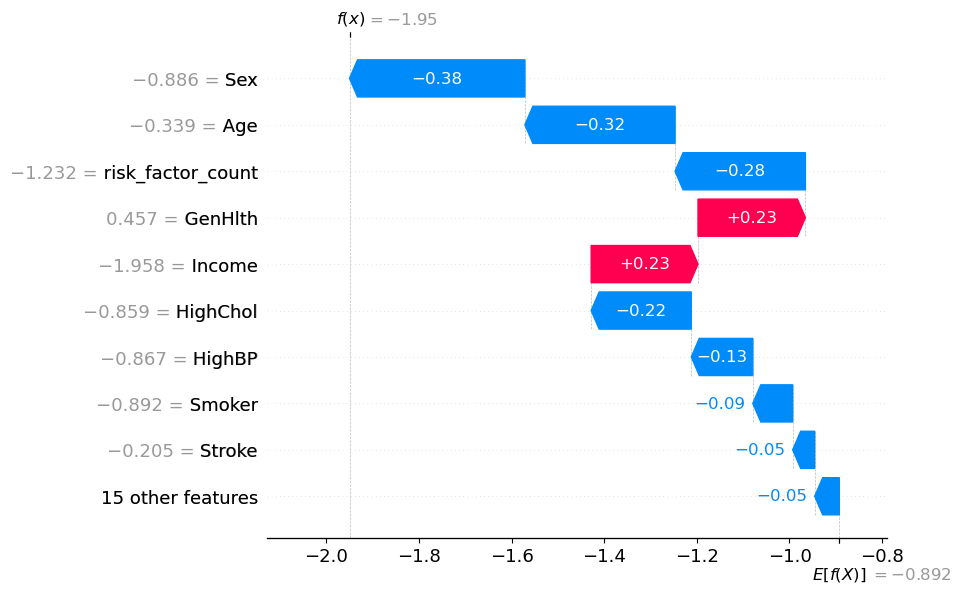

In [16]:
# Step 16: Create SHAP waterfall plot for one individual prediction

shap.plots.waterfall(shap_values[sample_index])

### Interpretation

This SHAP waterfall plot explains one individual prediction from the sample dataset.

The model predicted this individual as **No Heart Disease / Attack** with a predicted heart disease/attack probability of around **12.43%**.

In the waterfall plot, blue features pushed the prediction toward a lower heart disease/attack risk, while red features pushed the prediction toward a higher risk. For this individual, features such as sex, age, high cholesterol, high blood pressure, smoking status, stroke history, and difficulty walking pushed the prediction lower, while general health and income pushed the prediction slightly higher.

This type of explanation is useful for the final app because it can help show why the model produced a particular risk prediction.

In [17]:
# Step 17: Save SHAP feature importance results

shap_importance.to_csv("../models/shap_feature_importance.csv", index=False)

In [18]:
# Step 18: Confirm SHAP feature importance file saved

import os

os.listdir("../models")

['shap_feature_importance.csv',
 'scaler.pkl',
 'logistic_regression_model.pkl',
 'logistic_regression_feature_importance.csv',
 'app_feature_value_guide.csv',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv',
 'final_model_summary.csv',
 'app_preparation_summary.csv',
 'shap_sample_data.csv',
 'shap_explanation_summary.csv']

In [19]:
# Step 19: Load saved SHAP feature importance file

saved_shap_importance = pd.read_csv("../models/shap_feature_importance.csv")

saved_shap_importance.head(15)

,Feature,Mean Absolute SHAP Value
0,Age,0.686122
1,GenHlth,0.442938
2,Sex,0.408225
3,HighChol,0.227950
4,risk_factor_count,0.201181
5,HighBP,0.182037
6,Smoker,0.100845
7,Income,0.094528
8,Stroke,0.081061
9,NoDocbcCost,0.045830


### Interpretation

The SHAP feature importance results were saved so they can be used later in the dashboard, app explanation section, and capstone presentation.

In [20]:
# Step 20: Save SHAP sample data

X_sample.to_csv("../models/shap_sample_data.csv", index=False)

In [21]:
# Step 21: Confirm saved files

os.listdir("../models")

['shap_feature_importance.csv',
 'scaler.pkl',
 'logistic_regression_model.pkl',
 'logistic_regression_feature_importance.csv',
 'app_feature_value_guide.csv',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv',
 'final_model_summary.csv',
 'app_preparation_summary.csv',
 'shap_sample_data.csv',
 'shap_explanation_summary.csv']

In [22]:
# Step 22: Create SHAP explanation summary

shap_summary = {
    "Model Explained": "Logistic Regression",
    "SHAP Sample Size": len(X_sample),
    "Top Feature 1": shap_importance.iloc[0]["Feature"],
    "Top Feature 2": shap_importance.iloc[1]["Feature"],
    "Top Feature 3": shap_importance.iloc[2]["Feature"],
    "Top Feature 4": shap_importance.iloc[3]["Feature"],
    "Top Feature 5": shap_importance.iloc[4]["Feature"]
}

shap_summary

{'Model Explained': 'Logistic Regression',
 'SHAP Sample Size': 5000,
 'Top Feature 1': 'Age',
 'Top Feature 2': 'GenHlth',
 'Top Feature 3': 'Sex',
 'Top Feature 4': 'HighChol',
 'Top Feature 5': 'risk_factor_count'}

In [23]:
# Step 23: Convert SHAP explanation summary to DataFrame

shap_summary_df = pd.DataFrame([shap_summary])

shap_summary_df

,Model Explained,SHAP Sample Size,Top Feature 1,Top Feature 2,Top Feature 3,Top Feature 4,Top Feature 5
0,Logistic Regression,5000,Age,GenHlth,Sex,HighChol,risk_factor_count


In [24]:
# Step 24: Save SHAP explanation summary

shap_summary_df.to_csv("../models/shap_explanation_summary.csv", index=False)

In [25]:
# Step 25: Confirm all saved files

os.listdir("../models")

['shap_feature_importance.csv',
 'scaler.pkl',
 'logistic_regression_model.pkl',
 'logistic_regression_feature_importance.csv',
 'app_feature_value_guide.csv',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv',
 'final_model_summary.csv',
 'app_preparation_summary.csv',
 'shap_sample_data.csv',
 'shap_explanation_summary.csv']